In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

In [4]:
import sys
print(sys.executable)

/opt/homebrew/Caskroom/miniconda/base/bin/python


In [5]:
# Load Ames Housing
df = pd.read_csv("https://raw.githubusercontent.com/wblakecannon/ames/master/data/housing.csv")

# Work with a focused subset of columns
cols = [
    'SalePrice', 'Gr Liv Area', 'Lot Area', 'Year Built',
    'Overall Qual', 'Garage Cars', 'Lot Frontage',
    'Mas Vnr Area', 'Garage Yr Blt',
    'Exter Qual', 'Neighborhood', 'House Style',
    'Sale Condition', 'Bldg Type'
]
df = df[cols].copy()

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()

Shape: (2930, 14)

Missing values:
Garage Cars        1
Lot Frontage     490
Mas Vnr Area      23
Garage Yr Blt    159
dtype: int64


,SalePrice,Gr Liv Area,Lot Area,Year Built,Overall Qual,Garage Cars,Lot Frontage,Mas Vnr Area,Garage Yr Blt,Exter Qual,Neighborhood,House Style,Sale Condition,Bldg Type
0,215000,1656,31770,1960,6,2.0,141.0,112.0,1960.0,TA,NAmes,1Story,Normal,1Fam
1,105000,896,11622,1961,5,1.0,80.0,0.0,1961.0,TA,NAmes,1Story,Normal,1Fam
2,172000,1329,14267,1958,6,1.0,81.0,108.0,1958.0,TA,NAmes,1Story,Normal,1Fam
3,244000,2110,11160,1968,7,2.0,93.0,0.0,1968.0,Gd,NAmes,1Story,Normal,1Fam
4,189900,1629,13830,1997,5,2.0,74.0,0.0,1997.0,TA,Gilbert,2Story,Normal,1Fam


## **1. Handling Missing Values**

### 1a. Mean / Median / Mode Imputation


In [29]:
from sklearn.impute import SimpleImputer

df_imputed = df.copy()

# --- Mean imputation (numerical, roughly normal) ---
mean_imputer = SimpleImputer(strategy='mean')
df_imputed['Garage Yr Blt'] = mean_imputer.fit_transform(df_imputed[['Garage Yr Blt']])

# --- Median imputation (numerical, skewed — Lot Frontage is right-skewed) ---
median_imputer = SimpleImputer(strategy='median')
df_imputed['Lot Frontage'] = median_imputer.fit_transform(df_imputed[['Lot Frontage']])

# --- Mode imputation for Mas Vnr Area (has a few nulls) ---
mode_imputer = SimpleImputer(strategy='most_frequent')
df_imputed['Mas Vnr Area'] = mode_imputer.fit_transform(df_imputed[['Mas Vnr Area']])

print("Missing values after simple imputation:")
print(df_imputed.isnull().sum()[df_imputed.isnull().sum() > 0])
print("\nLot Frontage — Original median:", df['Lot Frontage'].median())
print("Lot Frontage — After median imputation mean:", df_imputed['Lot Frontage'].mean().round(2))

Missing values after simple imputation:
Garage Cars    1
dtype: int64

Lot Frontage — Original median: 68.0
Lot Frontage — After median imputation mean: 69.02


### 1b. KNN Imputer

In [30]:
from sklearn.impute import KNNImputer

df_knn = df.copy()

# KNNImputer works only on numerical columns
num_cols = ['Lot Frontage', 'Mas Vnr Area', 'Garage Yr Blt']

knn_imputer = KNNImputer(n_neighbors=5)
df_knn[num_cols] = knn_imputer.fit_transform(df_knn[num_cols])

# Compare approaches for Lot Frontage
comparison = pd.DataFrame({
    'Original (non-null mean)': [df['Lot Frontage'].mean()],
    'After Median Imputation':  [df_imputed['Lot Frontage'].mean()],
    'After KNN Imputation':     [df_knn['Lot Frontage'].mean()]
})
print("Lot Frontage mean comparison:")
print(comparison.round(2))

Lot Frontage mean comparison:
   Original (non-null mean)  After Median Imputation  After KNN Imputation
0                     69.22                    69.02                 68.83


## **2. Encoding**


In [31]:
df_enc = df_imputed.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col].fillna(df_enc[col].mode()[0], inplace=True)

print("Remaining nulls:", df_enc.isnull().sum().sum())
print("\nCategorical columns:")
print(df_enc.select_dtypes(include='object').nunique())

Remaining nulls: 1

Categorical columns:
Exter Qual         4
Neighborhood      28
House Style        8
Sale Condition     6
Bldg Type          5
dtype: int64


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_enc['House Style_label'] = le.fit_transform(df_enc['House Style'])

print("Label Encoding — House Style:")
print(dict(zip(le.classes_, range(len(le.classes_)))))
print("\nSample:")
print(df_enc[['House Style', 'House Style_label']].drop_duplicates().sort_values('House Style_label'))

Label Encoding — House Style:
{'1.5Fin': 0, '1.5Unf': 1, '1Story': 2, '2.5Fin': 3, '2.5Unf': 4, '2Story': 5, 'SFoyer': 6, 'SLvl': 7}

Sample:
    House Style  House Style_label
16       1.5Fin                  0
553      1.5Unf                  1
0        1Story                  2
752      2.5Fin                  3
192      2.5Unf                  4
4        2Story                  5
21       SFoyer                  6
54         SLvl                  7


In [33]:
from sklearn.preprocessing import OrdinalEncoder

# Exter Qual has a genuine order: Po < Fa < TA < Gd < Ex
quality_order = [['Po', 'Fa', 'TA', 'Gd', 'Ex']]

oe = OrdinalEncoder(categories=quality_order)
df_enc['Exter Qual_ordinal'] = oe.fit_transform(df_enc[['Exter Qual']])

print("Ordinal Encoding — Exter Qual (Po=0 → Ex=4):")
print(df_enc[['Exter Qual', 'Exter Qual_ordinal']].drop_duplicates().sort_values('Exter Qual_ordinal'))

Ordinal Encoding — Exter Qual (Po=0 → Ex=4):
    Exter Qual  Exter Qual_ordinal
205         Fa                 1.0
0           TA                 2.0
3           Gd                 3.0
15          Ex                 4.0


In [34]:
from sklearn.preprocessing import OneHotEncoder

# Bldg Type has 5 categories — perfect for OHE
print("Bldg Type unique values:", df_enc['Bldg Type'].nunique(), "→", df_enc['Bldg Type'].unique())

ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe.fit_transform(df_enc[['Bldg Type']])
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(['Bldg Type']), index=df_enc.index)

df_enc = pd.concat([df_enc, ohe_df], axis=1)
print("\nOHE columns added:")
print(ohe_df.head())

Bldg Type unique values: 5 → ['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']

OHE columns added:
   Bldg Type_2fmCon  Bldg Type_Duplex  Bldg Type_Twnhs  Bldg Type_TwnhsE
0               0.0               0.0              0.0               0.0
1               0.0               0.0              0.0               0.0
2               0.0               0.0              0.0               0.0
3               0.0               0.0              0.0               0.0
4               0.0               0.0              0.0               0.0


In [35]:
# Manual implementation to understand it clearly
# NOTE: In production, use cross-validation to prevent leakage

print("Neighborhood cardinality:", df_enc['Neighborhood'].nunique())

target_mean = df_enc.groupby('Neighborhood')['SalePrice'].mean()
df_enc['Neighborhood_target'] = df_enc['Neighborhood'].map(target_mean)

print("\nTop 5 Neighborhoods by avg SalePrice:")
print(target_mean.sort_values(ascending=False).head())
print("\nBottom 5 Neighborhoods by avg SalePrice:")
print(target_mean.sort_values().head())

Neighborhood cardinality: 28

Top 5 Neighborhoods by avg SalePrice:
Neighborhood
NoRidge    330319.126761
StoneBr    324229.196078
NridgHt    322018.265060
GrnHill    280000.000000
Veenker    248314.583333
Name: SalePrice, dtype: float64

Bottom 5 Neighborhoods by avg SalePrice:
Neighborhood
MeadowV     95756.486486
IDOTRR     103752.903226
BrDale     105608.333333
OldTown    123991.891213
BrkSide    124756.250000
Name: SalePrice, dtype: float64


In [13]:
freq_map = df_enc['Sale Condition'].value_counts(normalize=True)  # proportions
df_enc['Sale Condition_freq'] = df_enc['Sale Condition'].map(freq_map)

print("Frequency Encoding — Sale Condition:")
print(df_enc[['Sale Condition', 'Sale Condition_freq']].drop_duplicates().sort_values('Sale Condition_freq', ascending=False))

Frequency Encoding — Sale Condition:
     Sale Condition  Sale Condition_freq
0            Normal             0.823549
17          Partial             0.083618
89          Abnorml             0.064846
21           Family             0.015700
306          Alloca             0.008191
1500        AdjLand             0.004096


In [14]:
# Manual binary encoding
# Step 1: Label encode
le2 = LabelEncoder()
df_enc['Neighborhood_label'] = le2.fit_transform(df_enc['Neighborhood'])

# Step 2: Convert to binary and split into columns
n_bits = int(np.ceil(np.log2(df_enc['Neighborhood'].nunique())))

labels = df_enc['Neighborhood_label'].to_numpy().astype(np.int64)  # plain numpy array, bitwise-safe

for i in range(n_bits):
    df_enc[f'Neighborhood_bin_{i}'] = (labels >> i) & 1   # <-- use labels, not the Series

bin_cols = [f'Neighborhood_bin_{i}' for i in range(n_bits)]
print(f"Binary encoding: {df_enc['Neighborhood'].nunique()} categories → {n_bits} columns (vs 27 with OHE)")
print(df_enc[['Neighborhood', 'Neighborhood_label'] + bin_cols].drop_duplicates().head(8))

Binary encoding: 28 categories → 5 columns (vs 27 with OHE)
   Neighborhood  Neighborhood_label  Neighborhood_bin_0  Neighborhood_bin_1  \
0         NAmes                  15                   1                   1   
4       Gilbert                   8                   0                   0   
6       StoneBr                  25                   1                   0   
19       NWAmes                  17                   1                   0   
22      Somerst                  24                   0                   0   
29       BrDale                   2                   0                   1   
32      NPkVill                  16                   0                   0   
36      NridgHt                  19                   1                   1   

    Neighborhood_bin_2  Neighborhood_bin_3  Neighborhood_bin_4  
0                    1                   1                   0  
4                    0                   1                   0  
6                    0           

In [15]:
print(df_enc['Neighborhood_label'].dtype)

int64


## **3. Scaling**


In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer

# Use numerical features for scaling demo
scale_cols = ['Gr Liv Area', 'Lot Area', 'SalePrice', 'Year Built', 'Overall Qual']
X_scale = df_enc[scale_cols].copy()

X_train, X_test = train_test_split(X_scale, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (2344, 5) | Test shape: (586, 5)


#### 3a. Absolute Maximum Scaling

In [17]:
abs_max_scaler = MaxAbsScaler()
X_train_absmax = abs_max_scaler.fit_transform(X_train)
X_test_absmax  = abs_max_scaler.transform(X_test)

print("Absolute Maximum Scaling — scales each feature by its max absolute value → range [-1, 1]")
print("Max values after scaling:", np.abs(X_train_absmax).max(axis=0).round(4))
print("Min values after scaling:", X_train_absmax.min(axis=0).round(4))

Absolute Maximum Scaling — scales each feature by its max absolute value → range [-1, 1]
Max values after scaling: [1. 1. 1. 1. 1.]
Min values after scaling: [0.0592 0.006  0.0169 0.9313 0.1   ]


#### 3b. MinMax Scaling

In [18]:
mm_scaler = MinMaxScaler()   # default range [0, 1]
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm  = mm_scaler.transform(X_test)

print("MinMax Scaling — range [0, 1]")
print("Train min:", X_train_mm.min(axis=0).round(4))
print("Train max:", X_train_mm.max(axis=0).round(4))

MinMax Scaling — range [0, 1]
Train min: [0. 0. 0. 0. 0.]
Train max: [1. 1. 1. 1. 1.]


#### 3c. Normalization (L2 norm per row)

In [19]:
normalizer = Normalizer(norm='l2')   # l1 and max are also options
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm  = normalizer.transform(X_test)

# Each row's L2 norm = 1 after transformation
row_norms = np.linalg.norm(X_train_norm, axis=1)
print("Normalization (L2 per row) — all row norms = 1.0")
print("Sample row norms:", row_norms[:5].round(4))

Normalization (L2 per row) — all row norms = 1.0
Sample row norms: [1. 1. 1. 1. 1.]


#### 3d. Standardization (Z-score)

In [20]:
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std  = std_scaler.transform(X_test)

print("Standardization (Z-score) — mean=0, std=1")
print("Train mean (should be ~0):", X_train_std.mean(axis=0).round(4))
print("Train std  (should be ~1):", X_train_std.std(axis=0).round(4))

Standardization (Z-score) — mean=0, std=1
Train mean (should be ~0): [ 0.  0.  0. -0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1.]


#### 3e. Robust Scaling

Robust Scaling — uses median + IQR (not affected by outliers)
Train median (should be ~0): [0. 0. 0. 0. 0.]


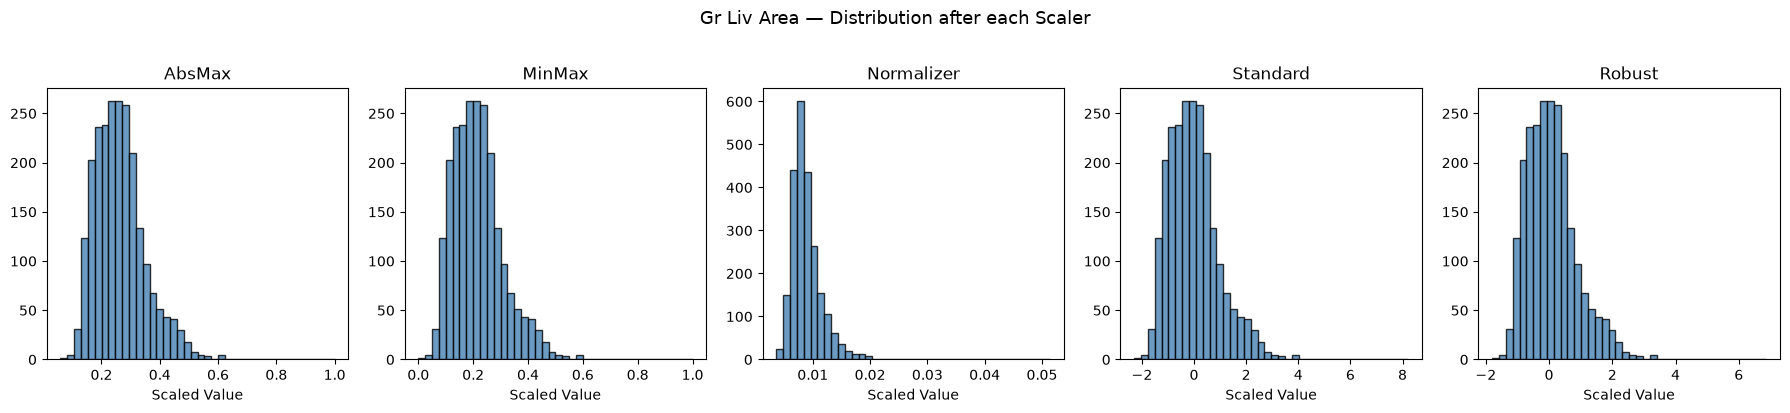

In [21]:
robust_scaler = RobustScaler()  # uses median and IQR — outlier resistant
X_train_rob = robust_scaler.fit_transform(X_train)
X_test_rob  = robust_scaler.transform(X_test)

print("Robust Scaling — uses median + IQR (not affected by outliers)")
print("Train median (should be ~0):", np.median(X_train_rob, axis=0).round(4))

# Visual comparison across scalers for Gr Liv Area
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
scalers_data = [
    (X_train_absmax[:, 0], 'AbsMax'),
    (X_train_mm[:, 0],     'MinMax'),
    (X_train_norm[:, 0],   'Normalizer'),
    (X_train_std[:, 0],    'Standard'),
    (X_train_rob[:, 0],    'Robust'),
]
for ax, (data, title) in zip(axes, scalers_data):
    ax.hist(data, bins=40, edgecolor='black', color='steelblue', alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Scaled Value')

plt.suptitle('Gr Liv Area — Distribution after each Scaler', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## **4. Transformation Techniques**

In [22]:
from scipy import stats
from sklearn.preprocessing import PowerTransformer

# Check skewness of our target and key feature
print("SalePrice skewness:", df_enc['SalePrice'].skew().round(3))
print("Lot Area skewness:",  df_enc['Lot Area'].skew().round(3))

SalePrice skewness: 1.744
Lot Area skewness: 12.821


#### 4a. Log Transformation

SalePrice skewness:
  Original : 1.744
  Log      : -0.015
  Log1p    : -0.015


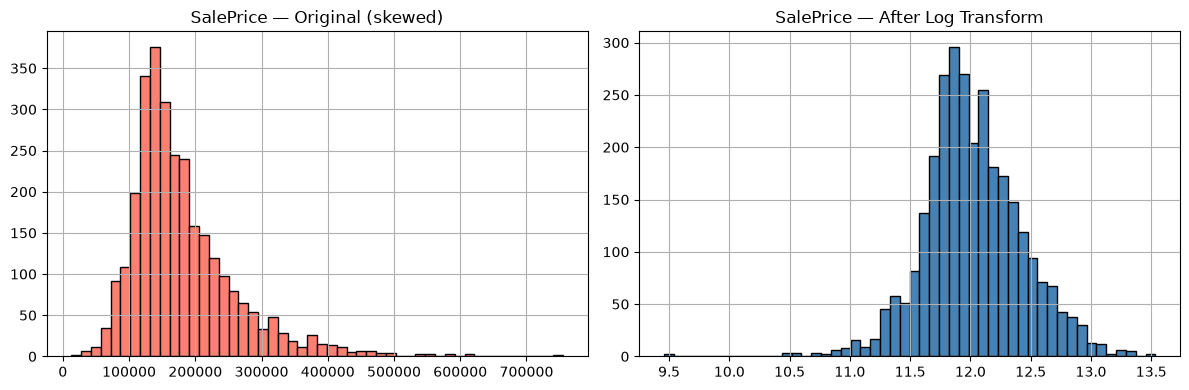

In [23]:
df_enc['SalePrice_log']  = np.log(df_enc['SalePrice'])       # natural log
df_enc['SalePrice_log1p'] = np.log1p(df_enc['SalePrice'])    # log(1+x) — safer if values can be 0
df_enc['Lot Area_log']   = np.log1p(df_enc['Lot Area'])

print("SalePrice skewness:")
print(f"  Original : {df_enc['SalePrice'].skew():.3f}")
print(f"  Log      : {df_enc['SalePrice_log'].skew():.3f}")
print(f"  Log1p    : {df_enc['SalePrice_log1p'].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_enc['SalePrice'].hist(bins=50, ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('SalePrice — Original (skewed)')
df_enc['SalePrice_log'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('SalePrice — After Log Transform')
plt.tight_layout()
plt.show()

#### 4b. Square Root Transformation

In [24]:
df_enc['Lot Area_sqrt'] = np.sqrt(df_enc['Lot Area'])

print("Lot Area skewness:")
print(f"  Original : {df_enc['Lot Area'].skew():.3f}")
print(f"  Sqrt     : {df_enc['Lot Area_sqrt'].skew():.3f}")
print(f"  Log1p    : {df_enc['Lot Area_log'].skew():.3f}")
print("\nNote: Log is stronger than sqrt for heavily skewed data")

Lot Area skewness:
  Original : 12.821
  Sqrt     : 3.068
  Log1p    : -0.498

Note: Log is stronger than sqrt for heavily skewed data


#### 4c. Box-Cox Transformation

In [25]:
# scipy Box-Cox (auto-finds lambda)
transformed_bc, lambda_bc = stats.boxcox(df_enc['SalePrice'])

print(f"Box-Cox optimal lambda: {lambda_bc:.4f}")
print(f"SalePrice skewness — Original: {df_enc['SalePrice'].skew():.3f}")
print(f"SalePrice skewness — Box-Cox:  {pd.Series(transformed_bc).skew():.3f}")

# sklearn PowerTransformer (Box-Cox)
pt_bc = PowerTransformer(method='box-cox')
df_enc['SalePrice_boxcox'] = pt_bc.fit_transform(df_enc[['SalePrice']])

Box-Cox optimal lambda: 0.0076
SalePrice skewness — Original: 1.744
SalePrice skewness — Box-Cox:  0.002


#### 4d. Yeo-Johnson Transformation

Transformation comparison — SalePrice skewness:
  Original       : 1.7435
  Log            : -0.0148
  Sqrt           : 0.8848
  Box-Cox        : 0.0015
  Yeo-Johnson    : 0.0015


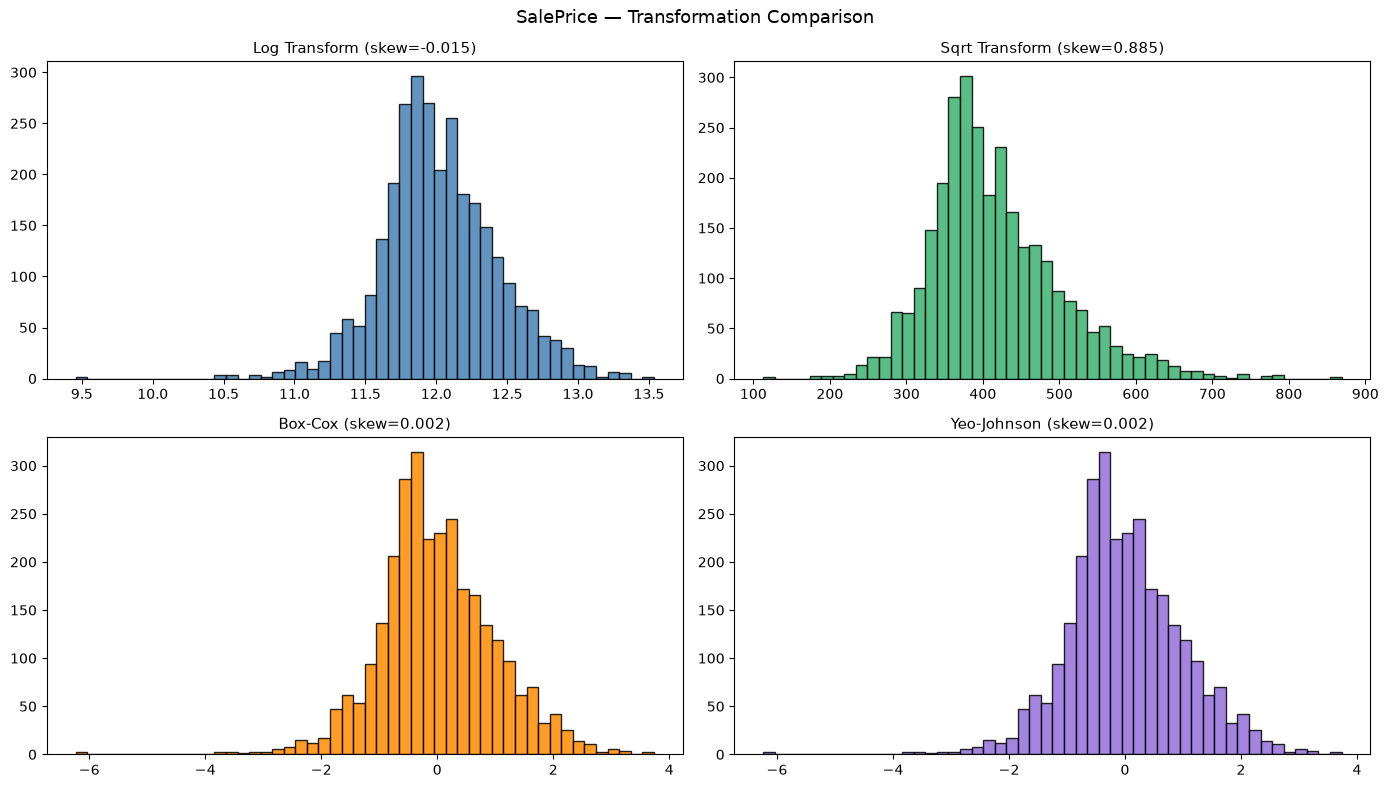

In [26]:
pt_yj = PowerTransformer(method='yeo-johnson')  # handles 0 and negatives
df_enc['SalePrice_yeojohnson'] = pt_yj.fit_transform(df_enc[['SalePrice']])

print("Transformation comparison — SalePrice skewness:")
results = {
    'Original':      df_enc['SalePrice'].skew(),
    'Log':           df_enc['SalePrice_log'].skew(),
    'Sqrt':          np.sqrt(df_enc['SalePrice']).skew(),
    'Box-Cox':       df_enc['SalePrice_boxcox'].skew(),
    'Yeo-Johnson':   df_enc['SalePrice_yeojohnson'].skew(),
}
for name, skew in results.items():
    print(f"  {name:<15}: {skew:.4f}")

# Visualize all 4 together
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_data = [
    (df_enc['SalePrice_log'],         'Log Transform'),
    (df_enc['SalePrice'].apply(np.sqrt), 'Sqrt Transform'),
    (df_enc['SalePrice_boxcox'],      'Box-Cox'),
    (df_enc['SalePrice_yeojohnson'],  'Yeo-Johnson'),
]
colors = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']
for ax, (data, title), color in zip(axes.flatten(), plot_data, colors):
    ax.hist(data, bins=50, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'{title} (skew={data.skew():.3f})', fontsize=11)
plt.suptitle('SalePrice — Transformation Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## **5. Feature Binning / Discretization**

#### 5a. pd.cut — Equal-width bins

In [27]:
# Equal-width bins: divides range into equal intervals
df_enc['SalePrice_cut'] = pd.cut(
    df_enc['SalePrice'],
    bins=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

print("pd.cut — Equal-width bins:")
print(df_enc['SalePrice_cut'].value_counts().sort_index())
print("\nNote: Unequal counts because SalePrice is right-skewed")

pd.cut — Equal-width bins:
SalePrice_cut
Very Low     1479
Low          1237
Medium        185
High           23
Very High       6
Name: count, dtype: int64

Note: Unequal counts because SalePrice is right-skewed


### 5b. pd.qcut — Equal-frequency bins (quantile-based)

In [28]:
# Quantile-based bins: each bin has equal number of samples
df_enc['SalePrice_qcut'] = pd.qcut(
    df_enc['SalePrice'],
    q=5,
    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
)

print("pd.qcut — Equal-frequency bins:")
print(df_enc['SalePrice_qcut'].value_counts().sort_index())
print("\nNote: Roughly equal counts — each bin has ~20% of data")

pd.qcut — Equal-frequency bins:
SalePrice_qcut
Q1    596
Q2    580
Q3    582
Q4    593
Q5    579
Name: count, dtype: int64

Note: Roughly equal counts — each bin has ~20% of data


### 5c. Year Built → Age group buckets

In [36]:
# Real-world example: convert Year Built to Age category
df_enc['House Age'] = 2010 - df_enc['Year Built']  # dataset ends ~2010

df_enc['Age Group'] = pd.cut(
    df_enc['House Age'],
    bins=[0, 10, 25, 50, 75, 200],
    labels=['New (0-10)', 'Recent (10-25)', 'Mid-age (25-50)', 'Old (50-75)', 'Very Old (75+)']
)

print("House Age Group distribution:")
print(df_enc['Age Group'].value_counts().sort_index())

House Age Group distribution:
Age Group
New (0-10)         780
Recent (10-25)     383
Mid-age (25-50)    792
Old (50-75)        557
Very Old (75+)     415
Name: count, dtype: int64


### 5d. KBinsDiscretizer (sklearn)
More control: encode as ordinal, OHE, or onehot-dense

In [37]:
from sklearn.preprocessing import KBinsDiscretizer

kbd = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
df_enc['Gr Liv Area_binned'] = kbd.fit_transform(df_enc[['Gr Liv Area']])

print("KBinsDiscretizer — Gr Liv Area into 5 quantile bins:")
print(df_enc['Gr Liv Area_binned'].value_counts().sort_index())
print("\nBin edges:", kbd.bin_edges_[0].round(0))

KBinsDiscretizer — Gr Liv Area into 5 quantile bins:
Gr Liv Area_binned
0.0    586
1.0    586
2.0    584
3.0    585
4.0    589
Name: count, dtype: int64

Bin edges: [ 334. 1064. 1328. 1560. 1838. 5642.]


## **6. Handling Outliers**

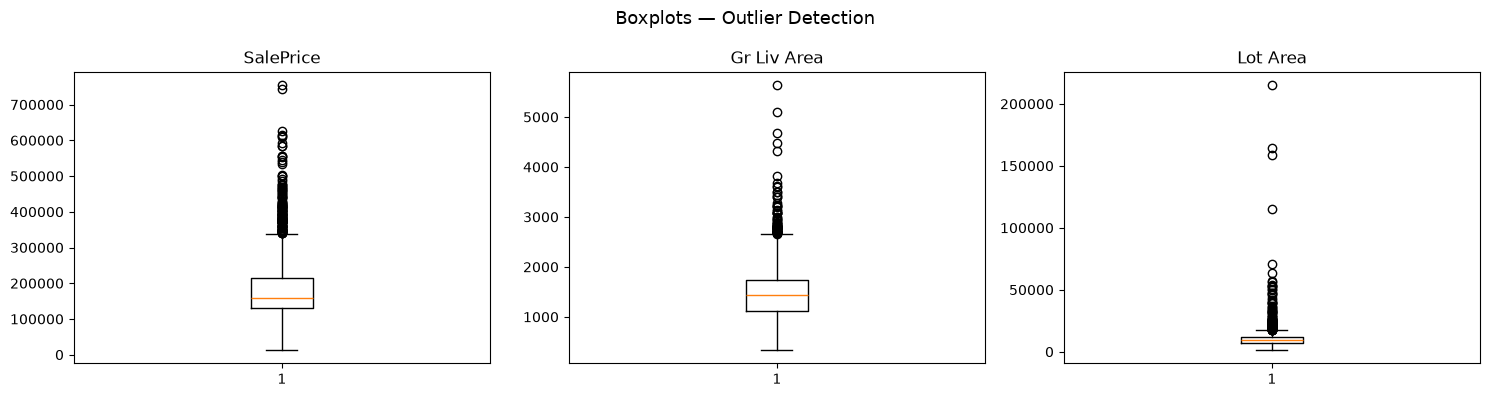

In [38]:
# Check for outliers visually first
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['SalePrice', 'Gr Liv Area', 'Lot Area']):
    ax.boxplot(df_enc[col].dropna())
    ax.set_title(col)
plt.suptitle('Boxplots — Outlier Detection', fontsize=13)
plt.tight_layout()
plt.show()

### 6a. IQR Method

In [39]:
def detect_outliers_iqr(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

for col in ['SalePrice', 'Gr Liv Area', 'Lot Area']:
    outliers, lower, upper = detect_outliers_iqr(df_enc[col])
    print(f"{col}: {len(outliers)} outliers | bounds [{lower:.0f}, {upper:.0f}]")

SalePrice: 137 outliers | bounds [3500, 339500]
Gr Liv Area: 75 outliers | bounds [201, 2668]
Lot Area: 127 outliers | bounds [1268, 17728]


### 6b. Z-Score Method

In [40]:
from scipy.stats import zscore

def detect_outliers_zscore(series, threshold=3):
    z_scores = np.abs(zscore(series.dropna()))
    return (z_scores > threshold).sum()

for col in ['SalePrice', 'Gr Liv Area', 'Lot Area']:
    n_outliers = detect_outliers_zscore(df_enc[col])
    print(f"{col}: {n_outliers} outliers (|z| > 3)")

print("\nNote: IQR and Z-score may disagree — IQR is more robust for skewed data")

SalePrice: 45 outliers (|z| > 3)
Gr Liv Area: 25 outliers (|z| > 3)
Lot Area: 29 outliers (|z| > 3)

Note: IQR and Z-score may disagree — IQR is more robust for skewed data


### 6c. Removing Outliers

In [41]:
df_clean = df_enc.copy()

# Remove using IQR bounds
_, lower_sp, upper_sp = detect_outliers_iqr(df_clean['SalePrice'])
before = len(df_clean)
df_clean = df_clean[(df_clean['SalePrice'] >= lower_sp) & (df_clean['SalePrice'] <= upper_sp)]
after = len(df_clean)

print(f"Rows before: {before} | After removing SalePrice outliers: {after} | Removed: {before - after}")

Rows before: 2930 | After removing SalePrice outliers: 2793 | Removed: 137


### 6d. Winsorization (Capping) — preferred over removal in most ML contexts

Lot Area — Winsorization (5th-95th percentile capping):
  Original  max: 17,140
  Winsorized max: 17,140
  Original  min: 3,182
  Winsorized min: 3,182


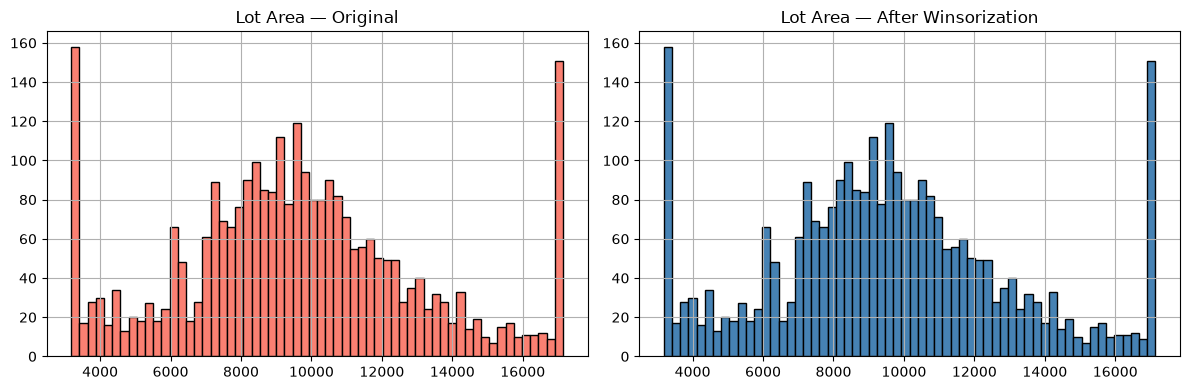

In [42]:
from scipy.stats.mstats import winsorize

# Cap at 5th and 95th percentile — outliers stay but are capped
df_enc['Lot Area_winsorized'] = winsorize(df_enc['Lot Area'], limits=[0.05, 0.05])

print("Lot Area — Winsorization (5th-95th percentile capping):")
print(f"  Original  max: {df_enc['Lot Area'].max():,.0f}")
print(f"  Winsorized max: {df_enc['Lot Area_winsorized'].max():,.0f}")
print(f"  Original  min: {df_enc['Lot Area'].min():,.0f}")
print(f"  Winsorized min: {df_enc['Lot Area_winsorized'].min():,.0f}")

# Visual: before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_enc['Lot Area'].hist(bins=60, ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Lot Area — Original')
df_enc['Lot Area_winsorized'].hist(bins=60, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Lot Area — After Winsorization')
plt.tight_layout()
plt.show()

### 6e. Manual Capping (without scipy)


In [43]:
# Clip to percentile bounds — common in production code
lower_pct = df_enc['Gr Liv Area'].quantile(0.05)
upper_pct = df_enc['Gr Liv Area'].quantile(0.95)

df_enc['Gr Liv Area_capped'] = df_enc['Gr Liv Area'].clip(lower=lower_pct, upper=upper_pct)

print("Gr Liv Area — Manual Capping (clip to 5th-95th percentile):")
print(f"  Original  range: [{df_enc['Gr Liv Area'].min():.0f}, {df_enc['Gr Liv Area'].max():.0f}]")
print(f"  Capped    range: [{df_enc['Gr Liv Area_capped'].min():.0f}, {df_enc['Gr Liv Area_capped'].max():.0f}]")

Gr Liv Area — Manual Capping (clip to 5th-95th percentile):
  Original  range: [334, 5642]
  Capped    range: [861, 2463]
